### PASO 3: ENTRENAR LA CNN CON AUGMENTATION REAL

### ¿Por qué falla la CNN actual? (el paso 3 original tampoco se incluye, por lo obvio)

Hay dos problemas separados:

**Problema 1 — Falsos positivos** (ve dígitos donde no los hay)
- El umbral de área del 4% es demasiado bajo
- Cualquier sombra o imperfección lo supera
- Solución: subir el umbral y añadir filtro de forma

**Problema 2 — Dígitos incorrectos** (reconoce mal los que sí existen)
- La CNN se entrenó con MNIST: dígitos manuscritos, blancos sobre negro
- Tus sudokus tienen dígitos **impresos**, con tipografía distinta
- Solución: reentrenar con augmentation que simule dígitos impresos

### Plan de este notebook

```
CELDA 1  → Instalaciones
CELDA 2  → Diagnóstico visual: ver exactamente qué llega a la CNN
CELDA 3  → Nuevo filtro de falsos positivos (umbral más agresivo)
CELDA 4  → Crear dataset aumentado que simule dígitos impresos
CELDA 5  → Ver ejemplos del dataset aumentado
CELDA 6  → Reentrenar la CNN con ese dataset
CELDA 7  → Evaluar la nueva CNN
CELDA 8  → Probar el pipeline completo con la nueva CNN
CELDA 9  → Guardar el nuevo modelo
```

#### CELDA 1 — Instalaciones e imports

In [ ]:
# ============================================
# INSTALACIONES E IMPORTS
# ============================================

from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics tensorflow opencv-python-headless -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO

RUTA_SUDOKU = '/content/drive/MyDrive/sudoku/'
RUTA_YOLO   = RUTA_SUDOKU + 'modelo_yolo.pt'
RUTA_CNN    = RUTA_SUDOKU + 'modelo_digitos.keras'
RUTA_TEST   = RUTA_SUDOKU + 'images/test/'
RUTA_TRAIN  = RUTA_SUDOKU + 'images/train/'

print("✅ Todo listo")
print(f"   TensorFlow: {tf.__version__}")
print(f"   OpenCV:     {cv2.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Todo listo
   TensorFlow: 2.20.0
   OpenCV:     4.13.0


#### CELDA 2 — Diagnóstico: ver exactamente qué le llega a la CNN

Celda prescindible.
Antes de cambiar nada, vamos a ver **todas las celdas** de una imagen
con su valor de área. Así entendemos por qué hay tantos falsos positivos
y por qué falla el reconocimiento.


image 1/1 /content/drive/MyDrive/sudoku/images/test/sudoku_3295_jpg.rf.FpFbVGMHTlUDCmSrYTCw.jpg: 640x480 1 sudoku_grid, 430.3ms
Speed: 19.7ms preprocess, 430.3ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 480)
🔍 Las 81 celdas preprocesadas (con % de área de píxeles blancos):
   Área baja → celda vacía | Área alta → hay algo (dígito o ruido)



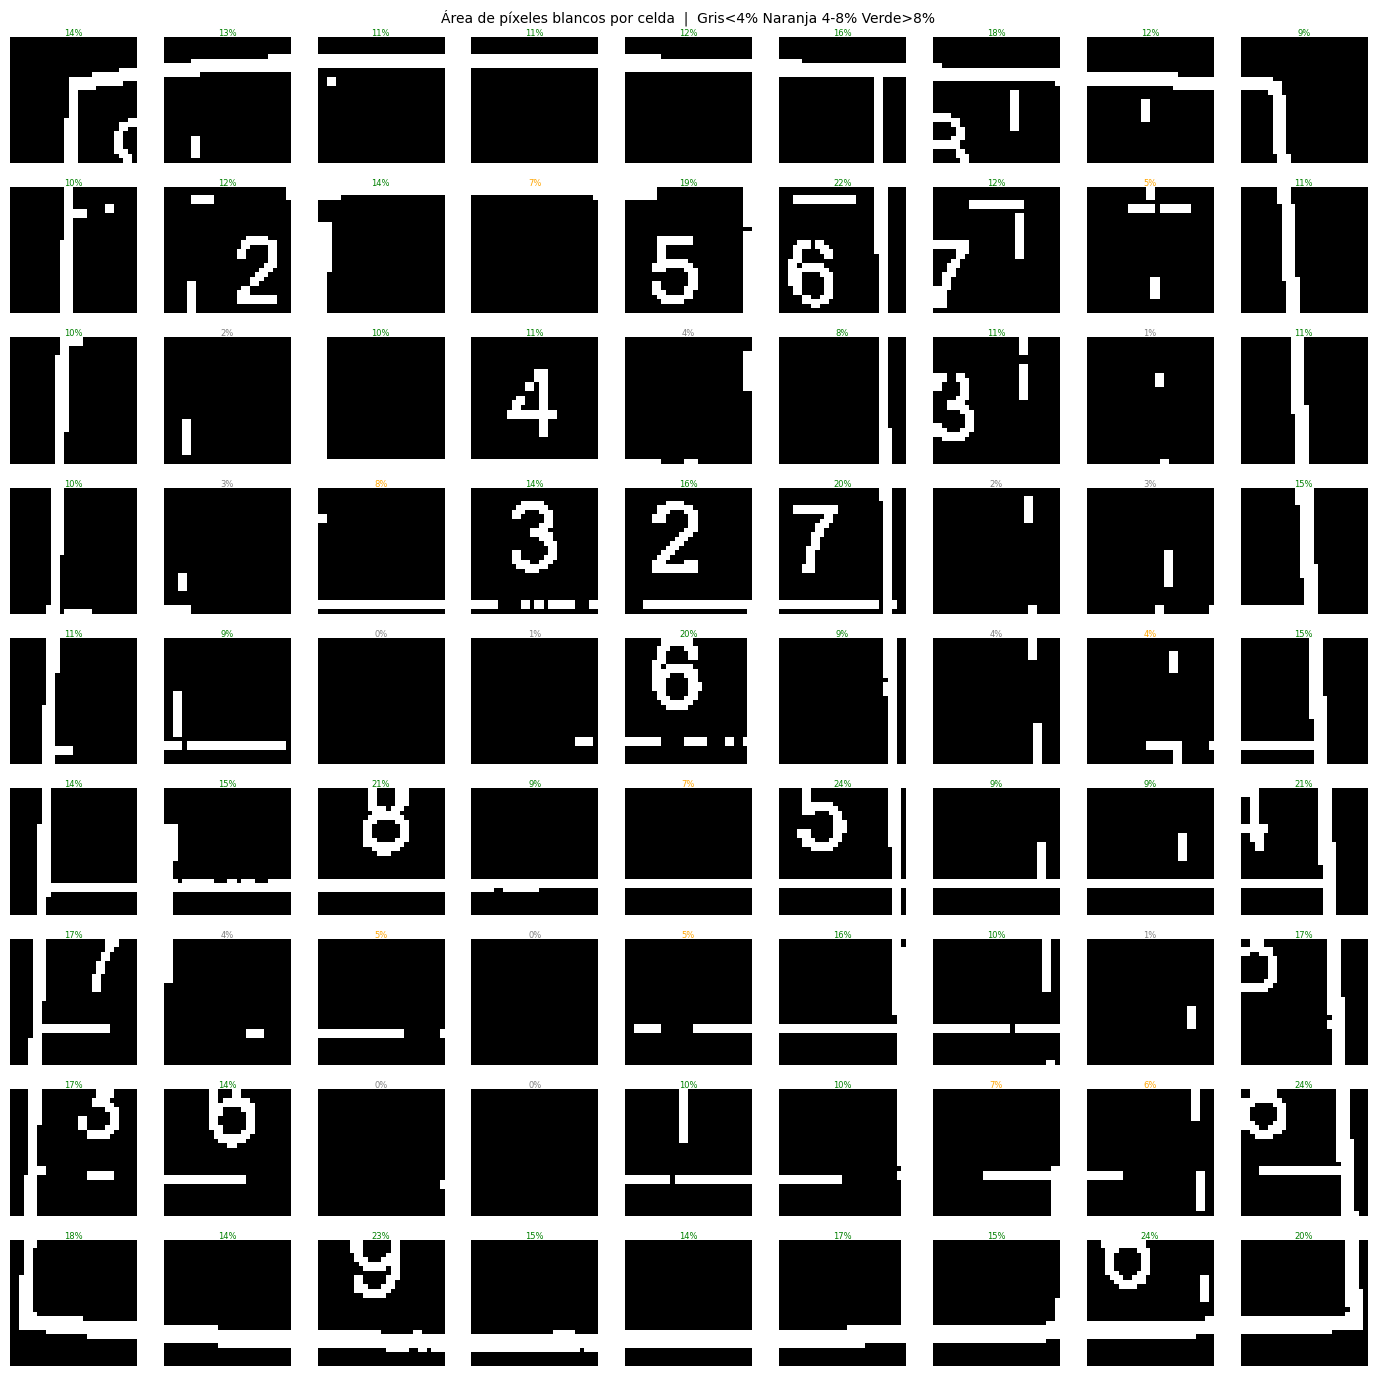


📊 Histograma de áreas (ayuda a elegir el umbral correcto):


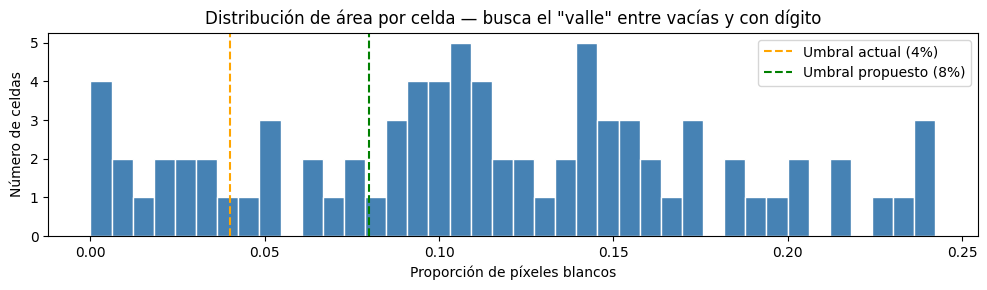


💡 Busca en el histograma si hay un 'valle' claro.
   Si las celdas vacías tienen área < X% y las con dígito > Y%,
   el umbral ideal está entre X e Y.


In [ ]:
# ============================================
# DIAGNÓSTICO COMPLETO DE UNA IMAGEN
# ============================================

# Reutilizamos preprocesar_celda del notebook anterior
def preprocesar_celda(celda_raw):
    alto, ancho = celda_raw.shape
    margen  = max(2, alto // 10)
    celda   = celda_raw[margen:-margen, margen:-margen]
    celda   = cv2.resize(celda, (28, 28))
    _, celda_bin = cv2.threshold(celda, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(celda_bin) > 127:
        celda_bin = cv2.bitwise_not(celda_bin)
    kernel    = np.ones((2, 2), np.uint8)
    celda_bin = cv2.morphologyEx(celda_bin, cv2.MORPH_OPEN, kernel)
    return celda_bin.astype('float32') / 255.0

# ── Cargar imagen y detectar cuadrícula ─────────────────────────────────
modelo_yolo   = YOLO(RUTA_YOLO)
imagen_test   = os.listdir(RUTA_TEST)[0]
ruta_completa = RUTA_TEST + imagen_test

img     = cv2.imread(ruta_completa)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = modelo_yolo(ruta_completa)
box     = results[0].boxes[0]
x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
grid    = img_rgb[y1:y2, x1:x2]
gray    = cv2.cvtColor(grid, cv2.COLOR_RGB2GRAY)

h, w   = gray.shape
cell_h = h // 9
cell_w = w // 9

# ── Mostrar las 81 celdas preprocesadas con su área ─────────────────────
print("🔍 Las 81 celdas preprocesadas (con % de área de píxeles blancos):")
print("   Área baja → celda vacía | Área alta → hay algo (dígito o ruido)")
print()

fig, axes = plt.subplots(9, 9, figsize=(14, 14))

areas = np.zeros((9, 9))

for i in range(9):
    for j in range(9):
        celda_raw  = gray[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
        celda_proc = preprocesar_celda(celda_raw)

        # Calcular área de píxeles blancos
        area = np.sum(celda_proc > 0.5) / (28 * 28)
        areas[i][j] = area

        ax = axes[i][j]
        ax.imshow(celda_proc, cmap='gray', vmin=0, vmax=1)

        # Color del título según el área
        if area < 0.04:
            color = 'gray'       # casi seguro vacío
        elif area < 0.08:
            color = 'orange'     # zona dudosa
        else:
            color = 'green'      # probablemente hay dígito

        ax.set_title(f'{area:.0%}', fontsize=6, color=color, pad=1)
        ax.axis('off')

plt.suptitle('Área de píxeles blancos por celda  |  Gris<4% Naranja 4-8% Verde>8%',
             fontsize=10)
plt.tight_layout()
plt.show()

# ── Histograma de áreas ──────────────────────────────────────────────────
print("\n📊 Histograma de áreas (ayuda a elegir el umbral correcto):")
todas_las_areas = areas.flatten()
plt.figure(figsize=(10, 3))
plt.hist(todas_las_areas, bins=40, color='steelblue', edgecolor='white')
plt.axvline(0.04, color='orange', linestyle='--', label='Umbral actual (4%)')
plt.axvline(0.08, color='green',  linestyle='--', label='Umbral propuesto (8%)')
plt.xlabel('Proporción de píxeles blancos')
plt.ylabel('Número de celdas')
plt.title('Distribución de área por celda — busca el "valle" entre vacías y con dígito')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Busca en el histograma si hay un 'valle' claro.")
print("   Si las celdas vacías tienen área < X% y las con dígito > Y%,")
print("   el umbral ideal está entre X e Y.")

#### CELDA 3 — Nuevo filtro de falsos positivos

Con lo visto en el diagnóstico, ajustamos el umbral.
Además añadimos un **filtro de forma**: un dígito real tiene una
relación de aspecto razonable (no es ni un punto ni una línea horizontal).

🔬 Comparando filtro ANTERIOR vs NUEVO en la primera fila:


/tmp/ipykernel_9282/1072806232.py:92: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9282/1072806232.py:92: UserWarning: Glyph 11036 (\N{WHITE LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


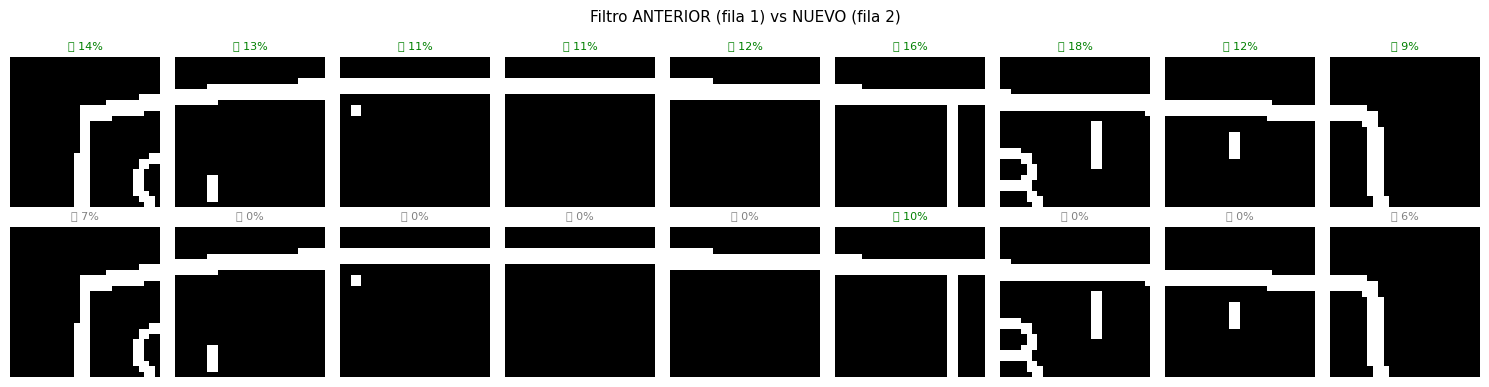


💡 Si el filtro nuevo sigue dando falsos positivos,
   sube umbral_area a 0.10 o 0.12 en la función hay_digito_v2()


In [ ]:
# ============================================
# FUNCIÓN MEJORADA: hay_digito()
# ============================================

def hay_digito_v2(celda_preprocesada,
                  umbral_area=0.05,       # bajar de 0.08 a 0.05%
    1. Área mínima del 8% (antes era 4%)
    2. Relación de aspecto del bounding box del contorno

    Un dígito real no puede ser casi cuadrado perfecto ni una línea fina.
    Una mancha de ruido suele ser casi redonda y muy pequeña.
    """
    celda_uint8 = (celda_preprocesada * 255).astype(np.uint8)

    contornos, _ = cv2.findContours(
        celda_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contornos:
        return False, 0.0

    AREA_MINIMA = 20               # píxeles absolutos mínimos
    AREA_MAXIMA = 0.85 * 28 * 28

    areas_validas = []
    for c in contornos:
        area_c = cv2.contourArea(c)
        if not (AREA_MINIMA < area_c < AREA_MAXIMA):
            continue

        # Filtro de forma: comprobar relación de aspecto
        x, y, w_c, h_c = cv2.boundingRect(c)
        if h_c == 0:
            continue
        aspecto = w_c / h_c

        # Si la relación de aspecto es absurda, es ruido
        if not (umbral_aspecto[0] < aspecto < umbral_aspecto[1]):
            continue

        areas_validas.append(area_c)

    if not areas_validas:
        return False, 0.0

    proporcion = sum(areas_validas) / (28 * 28)
    return proporcion > umbral_area, proporcion


# ── Probar el nuevo filtro en la misma imagen ────────────────────────────
print("🔬 Comparando filtro ANTERIOR vs NUEVO en la primera fila:")
print("="*50)

fig, axes = plt.subplots(2, 9, figsize=(15, 4))

for j in range(9):
    celda_raw  = gray[0:cell_h, j*cell_w:(j+1)*cell_w]
    celda_proc = preprocesar_celda(celda_raw)

    # Filtro anterior (4%)
    area        = np.sum(celda_proc > 0.5) / (28*28)
    tiene_viejo = area > 0.04

    # Filtro nuevo (8% + forma)
    tiene_nuevo, proporcion = hay_digito_v2(celda_proc)

    # Fila 0: filtro anterior
    axes[0][j].imshow(celda_proc, cmap='gray')
    axes[0][j].set_title(
        f'{"✅" if tiene_viejo else "⬜"} {area:.0%}',
        fontsize=8,
        color='green' if tiene_viejo else 'gray'
    )
    axes[0][j].axis('off')

    # Fila 1: filtro nuevo
    axes[1][j].imshow(celda_proc, cmap='gray')
    axes[1][j].set_title(
        f'{"✅" if tiene_nuevo else "⬜"} {proporcion:.0%}',
        fontsize=8,
        color='green' if tiene_nuevo else 'gray'
    )
    axes[1][j].axis('off')

axes[0][0].set_ylabel('Filtro anterior\n(4%)', fontsize=8, color='red')
axes[1][0].set_ylabel('Filtro nuevo\n(8% + forma)', fontsize=8, color='green')

plt.suptitle('Filtro ANTERIOR (fila 1) vs NUEVO (fila 2)', fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Si el filtro nuevo sigue dando falsos positivos,")
print("   sube umbral_area a 0.10 o 0.12 en la función hay_digito_v2()")

#### CELDA 4 — Crear dataset con augmentation que simule dígitos impresos

Esta es la clave para resolver el problema de reconocimiento.

Partimos de MNIST (dígitos 1-9) y aplicamos transformaciones que imitan
exactamente lo que ve la CNN en las celdas de un sudoku real:
- **Erosión/dilatación**: simula grosor de tinta variable
- **Ruido gaussiano**: simula granulado del papel
- **Rotación leve** (±5°): la foto nunca está perfecta
- **Desplazamiento**: el dígito no siempre está centrado
- **Variación de brillo**: iluminación no uniforme

In [ ]:
# ============================================
# CREAR DATASET CON AUGMENTATION REALISTA
# ============================================

print("📦 Cargando MNIST...")
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) =     keras.datasets.mnist.load_data()

print(f"   Train: {x_train_mnist.shape}  |  Test: {x_test_mnist.shape}")

# ── Filtrar solo clases 1-9 (en sudoku no existe el 0) ──────────────────
mask_train = y_train_mnist > 0
mask_test  = y_test_mnist  > 0

x_train_mnist = x_train_mnist[mask_train]
y_train_mnist = y_train_mnist[mask_train]
x_test_mnist  = x_test_mnist[mask_test]
y_test_mnist  = y_test_mnist[mask_test]

print(f"   Después de filtrar 0s → Train: {x_train_mnist.shape}")


def augmentar_digito(img_28x28):
    """
    Aplica transformaciones aleatorias a un dígito MNIST
    para que parezca un dígito impreso en sudoku.

    Entrada: imagen 28x28, valores 0-255 (uint8)
    Salida:  imagen 28x28 aumentada, valores 0-255 (uint8)
    """
    img = img_28x28.copy().astype(np.float32)

    # ── 1. Erosión o dilatación aleatoria ───────────────────────────────
    # Simula variaciones en el grosor de la tinta
    kernel_size = np.random.choice([1, 2, 3])
    kernel      = np.ones((kernel_size, kernel_size), np.uint8)
    img_uint8   = img.astype(np.uint8)

    if np.random.random() > 0.5:
        img_uint8 = cv2.erode(img_uint8, kernel, iterations=1)   # más delgado
    else:
        img_uint8 = cv2.dilate(img_uint8, kernel, iterations=1)  # más grueso
    img = img_uint8.astype(np.float32)

    # ── 2. Rotación leve ─────────────────────────────────────────────────
    # Las fotos no están perfectamente alineadas (±5 grados)
    angulo = np.random.uniform(-5, 5)
    M      = cv2.getRotationMatrix2D((14, 14), angulo, 1.0)
    img    = cv2.warpAffine(img, M, (28, 28))

    # ── 3. Desplazamiento ────────────────────────────────────────────────
    # El dígito no siempre está centrado en la celda (±3 píxeles)
    dx = np.random.randint(-3, 3)
    dy = np.random.randint(-3, 3)
    M  = np.float32([[1, 0, dx], [0, 1, dy]])
    img = cv2.warpAffine(img, M, (28, 28))

    # ── 4. Ruido gaussiano ───────────────────────────────────────────────
    # Simula el granulado del papel y la compresión JPEG
    ruido = np.random.normal(0, 15, img.shape).astype(np.float32)
    img   = np.clip(img + ruido, 0, 255)

    # ── 5. Variación de brillo ───────────────────────────────────────────
    # La iluminación no es uniforme en las fotos
    factor = np.random.uniform(0.8, 1.2)
    img    = np.clip(img * factor, 0, 255)

    return img.astype(np.uint8)


# ── Generar el dataset aumentado ─────────────────────────────────────────
# Por cada imagen original, creamos N_AUG versiones aumentadas
N_AUG = 8   # 5 versiones por imagen → 5x más datos

print(f"\n🔄 Generando dataset aumentado ({N_AUG} versiones por imagen)...")
print(f"   Esto puede tardar 1-2 minutos...")

x_aug_list = []
y_aug_list = []

for idx in range(len(x_train_mnist)):
    img_orig = x_train_mnist[idx]   # imagen original (28x28, uint8)

    # Incluir la imagen original también
    x_aug_list.append(img_orig)
    y_aug_list.append(y_train_mnist[idx])

    # Generar N_AUG versiones aumentadas
    for _ in range(N_AUG):
        img_aug = augmentar_digito(img_orig)
        x_aug_list.append(img_aug)
        y_aug_list.append(y_train_mnist[idx])

    if (idx + 1) % 10000 == 0:
        print(f"   Procesadas {idx+1}/{len(x_train_mnist)} imágenes...")

x_aug = np.array(x_aug_list, dtype=np.float32) / 255.0   # normalizar [0,1]
y_aug = np.array(y_aug_list, dtype=np.int32)

# Añadir dimensión de canal (requerida por la CNN)
x_aug        = x_aug.reshape(-1, 28, 28, 1)
x_test_norm  = x_test_mnist.astype(np.float32) / 255.0
x_test_norm  = x_test_norm.reshape(-1, 28, 28, 1)

print(f"\n✅ Dataset aumentado creado:")
print(f"   Train: {x_aug.shape}  ({len(x_aug):,} imágenes)")
print(f"   Test:  {x_test_norm.shape}")

📦 Cargando MNIST...
   Train: (60000, 28, 28)  |  Test: (10000, 28, 28)
   Después de filtrar 0s → Train: (54077, 28, 28)

🔄 Generando dataset aumentado (8 versiones por imagen)...
   Esto puede tardar 1-2 minutos...
   Procesadas 10000/54077 imágenes...
   Procesadas 20000/54077 imágenes...
   Procesadas 30000/54077 imágenes...
   Procesadas 40000/54077 imágenes...
   Procesadas 50000/54077 imágenes...

✅ Dataset aumentado creado:
   Train: (486693, 28, 28, 1)  (486,693 imágenes)
   Test:  (9020, 28, 28, 1)


#### CELDA 5 — Ver ejemplos del dataset aumentado

🎨 Ejemplos del dataset aumentado:
   Fila superior: imágenes ORIGINALES de MNIST
   Filas inferiores: versiones aumentadas


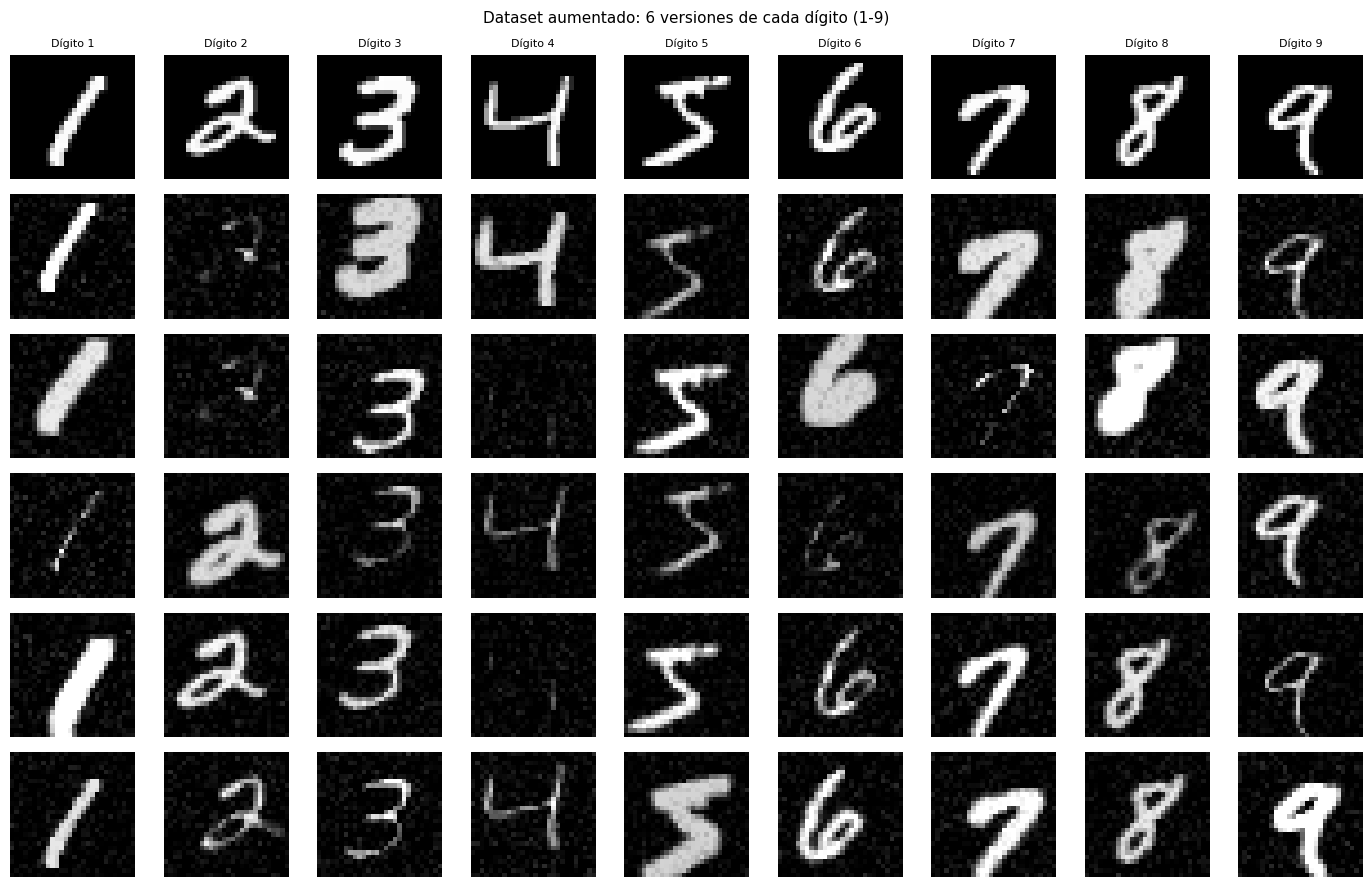


💡 Las versiones aumentadas deben verse algo distintas pero reconocibles.
   Si se ven irreconocibles, reduce los valores en augmentar_digito()


In [ ]:
# ============================================
# VISUALIZAR EL DATASET AUMENTADO
# ============================================

print("🎨 Ejemplos del dataset aumentado:")
print("   Fila superior: imágenes ORIGINALES de MNIST")
print("   Filas inferiores: versiones aumentadas")

# Elegir un dígito de cada clase (1-9) para mostrar
fig, axes = plt.subplots(6, 9, figsize=(14, 9))

for digito in range(1, 10):
    # Encontrar índices de este dígito en el dataset aumentado
    indices = np.where(y_aug.flatten() == digito)[0]

    col = digito - 1   # columna 0-8

    # Mostrar 6 versiones de cada dígito
    for fila in range(6):
        if fila < len(indices):
            img = x_aug[indices[fila]].reshape(28, 28)
            axes[fila][col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[fila][col].axis('off')

        if fila == 0:
            axes[fila][col].set_title(f'Dígito {digito}', fontsize=8)

    # Etiquetar filas
axes[0][0].set_ylabel('Original', fontsize=7, rotation=0, labelpad=35)
for f in range(1, 6):
    axes[f][0].set_ylabel(f'Aug {f}', fontsize=7, rotation=0, labelpad=30)

plt.suptitle('Dataset aumentado: 6 versiones de cada dígito (1-9)', fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Las versiones aumentadas deben verse algo distintas pero reconocibles.")
print("   Si se ven irreconocibles, reduce los valores en augmentar_digito()")

#### CELDA 6 — Reentrenar la CNN con el dataset aumentado

Usamos la misma arquitectura de antes pero la entrenamos con los datos
aumentados. Añadimos **Batch Normalization** que hace la red más robusta
a variaciones de brillo y contraste.

In [22]:
# ============================================
# REENTRENAR LA CNN
# ============================================

def crear_cnn_mejorada():
    """
    Misma arquitectura que antes pero con Batch Normalization.
    Batch Normalization normaliza la activación de cada capa,
    haciendo la red más robusta a variaciones de iluminación.
    """
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        # Bloque 1
        keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),   # ← NUEVO: normaliza activaciones
        keras.layers.MaxPooling2D((2, 2)),

        # Bloque 2
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),   # ← NUEVO
        keras.layers.MaxPooling2D((2, 2)),

        # Bloque 3 (nuevo: más capacidad para distinguir tipografías)
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),

        # Clasificador
        keras.layers.Flatten(),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(10, activation='softmax')   # 10 clases (0-9, aunque 0 no se usa)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Crear y entrenar ─────────────────────────────────────────────────────
print("🏗️  Creando CNN mejorada...")
modelo_cnn_nuevo = crear_cnn_mejorada()
modelo_cnn_nuevo.summary()

print("\n🚀 INICIANDO ENTRENAMIENTO...")
print("   Dataset: {:,} imágenes aumentadas".format(len(x_aug)))
print("   Épocas: 10")
print("="*50)

# Callback: reduce el learning rate si no mejora en 2 épocas
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1
)

history = modelo_cnn_nuevo.fit(
    x_aug, y_aug,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[reduce_lr],
    verbose=1
)

# ── Evaluar en test ──────────────────────────────────────────────────────
test_loss, test_acc = modelo_cnn_nuevo.evaluate(x_test_norm, y_test_mnist, verbose=0)
print(f"\n✅ Precisión en test MNIST: {test_acc:.2%}")

🏗️  Creando CNN mejorada...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,026 (6.49 MB)

 Trainable params: 1,701,578 (6.49 MB)

 Non-trainable params: 448 (1.75 KB)


🚀 INICIANDO ENTRENAMIENTO...
   Dataset: 486,693 imágenes aumentadas
   Épocas: 10
Epoch 1/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 1006s 586ms/step - accuracy: 0.9335 - loss: 0.2047 - val_accuracy: 0.9598 - val_loss: 0.1286 - learning_rate: 0.0010
Epoch 2/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 1035s 582ms/step - accuracy: 0.9623 - loss: 0.1133 - val_accuracy: 0.9653 - val_loss: 0.1137 - learning_rate: 0.0010
Epoch 3/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 1005s 587ms/step - accuracy: 0.9676 - loss: 0.0963 - val_accuracy: 0.9690 - val_loss: 0.1016 - learning_rate: 0.0010
Epoch 4/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 1030s 580ms/step - accuracy: 0.9714 - loss: 0.0839 - val_accuracy: 0.9678 - val_loss: 0.1094 - learning_rate: 0.0010
Epoch 5/10
1711/1712 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9720 - loss: 0.0825
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 1014s 592ms/step - accuracy: 0.9733 - loss: 0.0781 - val_accuracy: 0.9698 - val_los

#### CELDA 7 — Evaluar la nueva CNN: curvas de entrenamiento y matriz de confusión

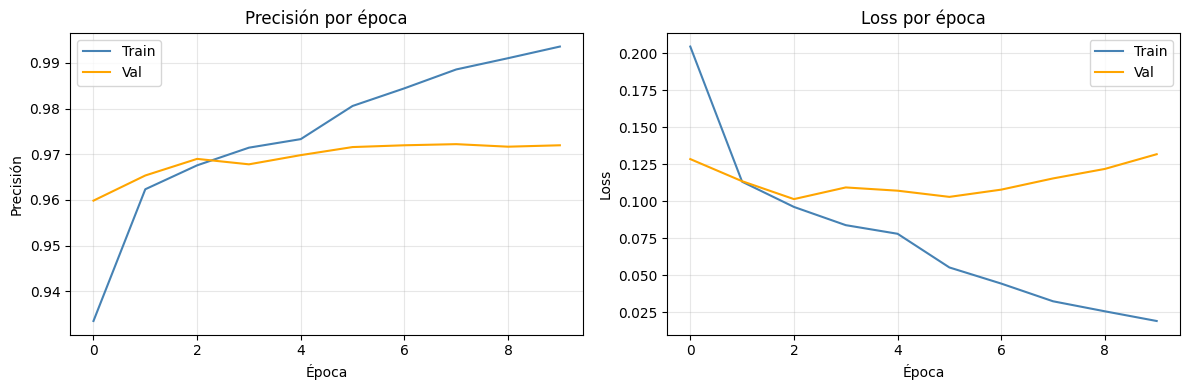


📊 Matriz de confusión en el conjunto de test (clases 1-9):
   Filas = dígito real | Columnas = dígito predicho
   Una diagonal perfecta significa que no hay confusiones


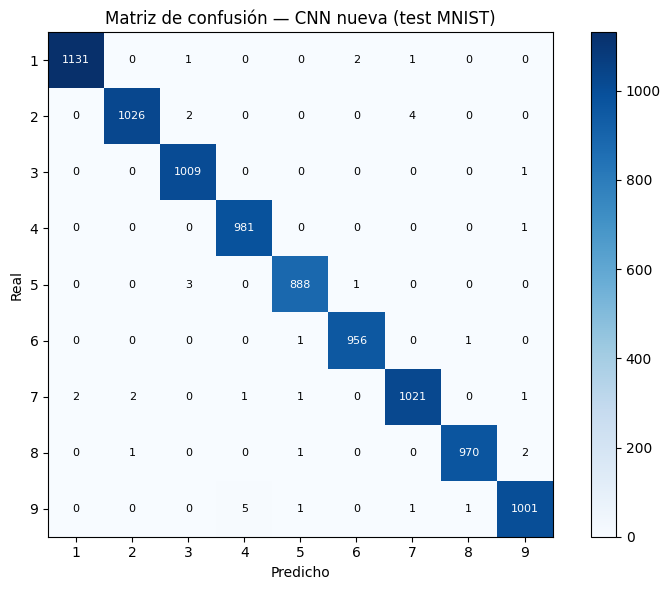


💡 Las confusiones más comunes en MNIST son 1↔7, 3↔8, 4↔9.
   Si las ves aquí, es normal. Lo importante es que la diagonal sea alta.


In [23]:
# ============================================
# EVALUAR LA NUEVA CNN
# ============================================

# ── Curvas de entrenamiento ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('Precisión por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Matriz de confusión (clases 1-9) ────────────────────────────────────
print("\n📊 Matriz de confusión en el conjunto de test (clases 1-9):")
print("   Filas = dígito real | Columnas = dígito predicho")
print("   Una diagonal perfecta significa que no hay confusiones")

predicciones = modelo_cnn_nuevo.predict(x_test_norm, verbose=0)
pred_clases  = np.argmax(predicciones, axis=1)

# Solo clases 1-9
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_mnist, pred_clases, labels=list(range(1, 10)))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(9))
ax.set_yticks(range(9))
ax.set_xticklabels(range(1, 10))
ax.set_yticklabels(range(1, 10))
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — CNN nueva (test MNIST)')

# Añadir valores dentro de la matriz
for i in range(9):
    for j in range(9):
        valor = cm[i, j]
        color = 'white' if valor > cm.max() / 2 else 'black'
        ax.text(j, i, str(valor), ha='center', va='center',
                fontsize=8, color=color)

plt.tight_layout()
plt.show()

print("\n💡 Las confusiones más comunes en MNIST son 1↔7, 3↔8, 4↔9.")
print("   Si las ves aquí, es normal. Lo importante es que la diagonal sea alta.")

#### CELDA 8 — Probar el pipeline completo con la nueva CNN

Ahora probamos todo junto: nuevo filtro + nueva CNN.

🔬 Probando pipeline completo con la nueva CNN...

image 1/1 /content/drive/MyDrive/sudoku/images/test/sudoku_3295_jpg.rf.FpFbVGMHTlUDCmSrYTCw.jpg: 640x480 1 sudoku_grid, 217.0ms
Speed: 8.3ms preprocess, 217.0ms inference, 7.6ms postprocess per image at shape (1, 3, 640, 480)

📊 Dígitos detectados: 17/81

📊 MATRIZ DETECTADA (. = vacío):
   ┌─────────┬─────────┬─────────┐
   │ . . . │ . . 7 │ . . . │
   │ . . . │ . . 2 │ . . . │
   │ . . . │ . . . │ . . . │
   ├─────────┼─────────┼─────────┤
   │ . . . │ . . . │ . . 1 │
   │ . . . │ . 5 . │ . . 1 │
   │ . 2 1 │ . . 4 │ . . 1 │
   ├─────────┼─────────┼─────────┤
   │ . . . │ . . 2 │ . . . │
   │ . 1 . │ . . . │ . . 4 │
   │ 6 . . │ . . 2 │ 2 1 2 │
   └─────────┴─────────┴─────────┘

🔍 Celdas donde se detectó un dígito:


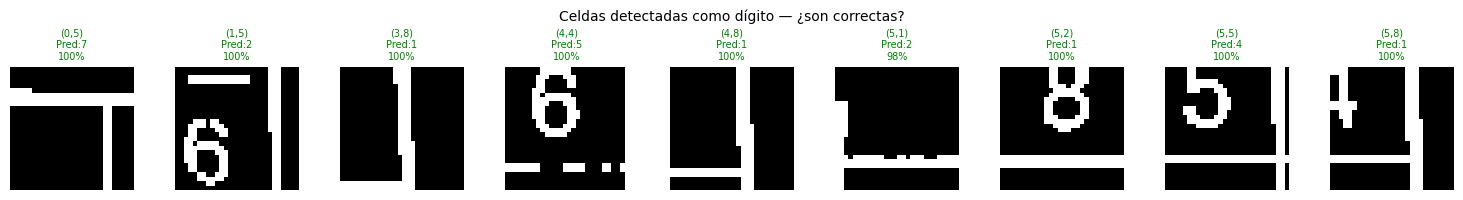

In [24]:
# ============================================
# FUNCIONES ACTUALIZADAS DEL PIPELINE
# ============================================

# (Copiamos las funciones con las mejoras de este notebook)

def preprocesar_celda(celda_raw):
    alto, ancho = celda_raw.shape
    margen      = max(2, alto // 10)
    celda       = celda_raw[margen:-margen, margen:-margen]
    celda       = cv2.resize(celda, (28, 28))
    _, celda_bin = cv2.threshold(celda, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(celda_bin) > 127:
        celda_bin = cv2.bitwise_not(celda_bin)
    kernel    = np.ones((2, 2), np.uint8)
    celda_bin = cv2.morphologyEx(celda_bin, cv2.MORPH_OPEN, kernel)
    return celda_bin.astype('float32') / 255.0


def hay_digito_v2(celda_preprocesada, umbral_area=0.08):
    celda_uint8 = (celda_preprocesada * 255).astype(np.uint8)
    contornos, _ = cv2.findContours(
        celda_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contornos:
        return False, 0.0
    areas_validas = []
    for c in contornos:
        area_c = cv2.contourArea(c)
        if not (20 < area_c < 0.85 * 28 * 28):
            continue
        x, y, w_c, h_c = cv2.boundingRect(c)
        if h_c == 0:
            continue
        aspecto = w_c / h_c
        if not (0.2 < aspecto < 5.0):
            continue
        areas_validas.append(area_c)
    if not areas_validas:
        return False, 0.0
    proporcion = sum(areas_validas) / (28 * 28)
    return proporcion > umbral_area, proporcion


def reconocer_digito(celda_preprocesada, modelo_cnn, umbral_confianza=0.70):
    celda_input = celda_preprocesada.reshape(1, 28, 28, 1)
    pred        = modelo_cnn.predict(celda_input, verbose=0)[0]
    pred[0]     = 0.0                  # eliminar clase 0 (no existe en sudoku)
    pred        = pred / pred.sum()
    digito      = int(np.argmax(pred))
    confianza   = float(pred[digito])
    if confianza < umbral_confianza:
        return 0, confianza
    return digito, confianza


def procesar_celda(celda_raw, modelo_cnn):
    celda_proc        = preprocesar_celda(celda_raw)
    tiene, proporcion = hay_digito_v2(celda_proc)
    if not tiene:
        return 0, 1.0, 'Vacío'
    digito, confianza = reconocer_digito(celda_proc, modelo_cnn)
    if digito == 0:
        return 0, confianza, 'Dudoso'
    return digito, confianza, 'CNN'


# ── Probar con la imagen de test ─────────────────────────────────────────
print("🔬 Probando pipeline completo con la nueva CNN...")
print("="*60)

results  = modelo_yolo(ruta_completa)
box      = results[0].boxes[0]
x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
grid     = img_rgb[y1:y2, x1:x2]
gray     = cv2.cvtColor(grid, cv2.COLOR_RGB2GRAY)
h, w     = gray.shape
cell_h   = h // 9
cell_w   = w // 9

matriz      = np.zeros((9, 9), dtype=int)
matriz_conf = np.zeros((9, 9))

for i in range(9):
    for j in range(9):
        celda_raw = gray[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
        digito, conf, estado = procesar_celda(celda_raw, modelo_cnn_nuevo)
        if digito > 0:
            matriz[i][j]      = digito
            matriz_conf[i][j] = conf

n_digitos = int(np.sum(matriz > 0))
print(f"\n📊 Dígitos detectados: {n_digitos}/81")

print("\n📊 MATRIZ DETECTADA (. = vacío):")
print("   ┌─────────┬─────────┬─────────┐")
for i, fila in enumerate(matriz):
    if i > 0 and i % 3 == 0:
        print("   ├─────────┼─────────┼─────────┤")
    fila_str = ""
    for j, n in enumerate(fila):
        if j % 3 == 0: fila_str += "│ "
        fila_str += (str(int(n)) if n != 0 else ".") + " "
    fila_str += "│"
    print(f"   {fila_str}")
print("   └─────────┴─────────┴─────────┘")

# ── Comparación visual: 9 celdas con dígito ─────────────────────────────
print("\n🔍 Celdas donde se detectó un dígito:")
posiciones_con_digito = [(i, j) for i in range(9) for j in range(9)
                         if matriz[i][j] > 0][:9]  # mostrar las primeras 9

if posiciones_con_digito:
    fig, axes = plt.subplots(1, len(posiciones_con_digito), figsize=(15, 2))
    if len(posiciones_con_digito) == 1:
        axes = [axes]
    for idx, (i, j) in enumerate(posiciones_con_digito):
        celda_raw  = gray[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
        celda_proc = preprocesar_celda(celda_raw)
        axes[idx].imshow(celda_proc, cmap='gray')
        axes[idx].set_title(
            f'({i},{j})\nPred:{matriz[i][j]}\n{matriz_conf[i][j]:.0%}',
            fontsize=7, color='green'
        )
        axes[idx].axis('off')
    plt.suptitle('Celdas detectadas como dígito — ¿son correctas?', fontsize=10)
    plt.tight_layout()
    plt.show()

#### CELDA 9 — Guardar el nuevo modelo

In [25]:
# ============================================
# GUARDAR EL NUEVO MODELO
# ============================================

RUTA_CNN_NUEVA = RUTA_SUDOKU + 'modelo_digitos_v2.keras'

modelo_cnn_nuevo.save(RUTA_CNN_NUEVA)
print(f"✅ Modelo guardado en: {RUTA_CNN_NUEVA}")

# Verificar
if os.path.exists(RUTA_CNN_NUEVA):
    tamaño = os.path.getsize(RUTA_CNN_NUEVA) / (1024 * 1024)
    print(f"   Tamaño: {tamaño:.1f} MB")

print("\n📌 Para usar este modelo en el Paso 3b, cambia:")
print(f"   RUTA_CNN = '{RUTA_CNN_NUEVA}'")
print("\n💡 Si los resultados todavía no son buenos, prueba:")
print("   1. Subir N_AUG a 8 o 10 en la celda 4")
print("   2. Subir umbral_area a 0.10 en hay_digito_v2()")
print("   3. Subir umbral_confianza a 0.80 en reconocer_digito()")

✅ Modelo guardado en: /content/drive/MyDrive/sudoku/modelo_digitos_v2.keras
   Tamaño: 19.5 MB

📌 Para usar este modelo en el Paso 3b, cambia:
   RUTA_CNN = '/content/drive/MyDrive/sudoku/modelo_digitos_v2.keras'

💡 Si los resultados todavía no son buenos, prueba:
   1. Subir N_AUG a 8 o 10 en la celda 4
   2. Subir umbral_area a 0.10 en hay_digito_v2()
   3. Subir umbral_confianza a 0.80 en reconocer_digito()
